In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


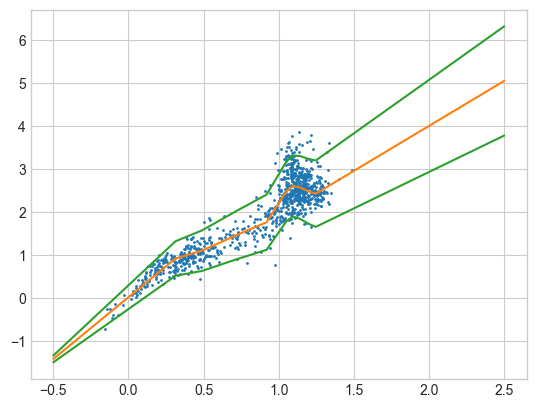

In [ ]:
# from ExoRM.get_data import get_data
# get_data()

# from ExoRM.initialize_model import initialize_model
# initialize_model()

# Use these to initialize / update the model

In [3]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data, read_exoplanet_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = True # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'

data = read_rm_data()
data = preprocess_data(data)

data

,name,radius,mass,density
0,2MASS J02192210-3925225 b,16.140960,4417.837000,1.050562
1,55 Cnc e,1.910000,8.080000,1.159608
2,BD-14 3065 b,21.590000,3932.000000,0.390711
3,CFHTWIR-Oph 98 b,20.848704,2479.061575,0.273558
4,CoRoT-1 b,16.700000,327.350000,0.070285
...,...,...,...,...
939,XO-3 b,13.641000,3747.060000,1.476223
940,XO-4 b,14.910000,565.710000,0.170671
941,XO-5 b,12.780000,378.200000,0.181188
942,XO-7 b,15.356304,225.658169,0.062315


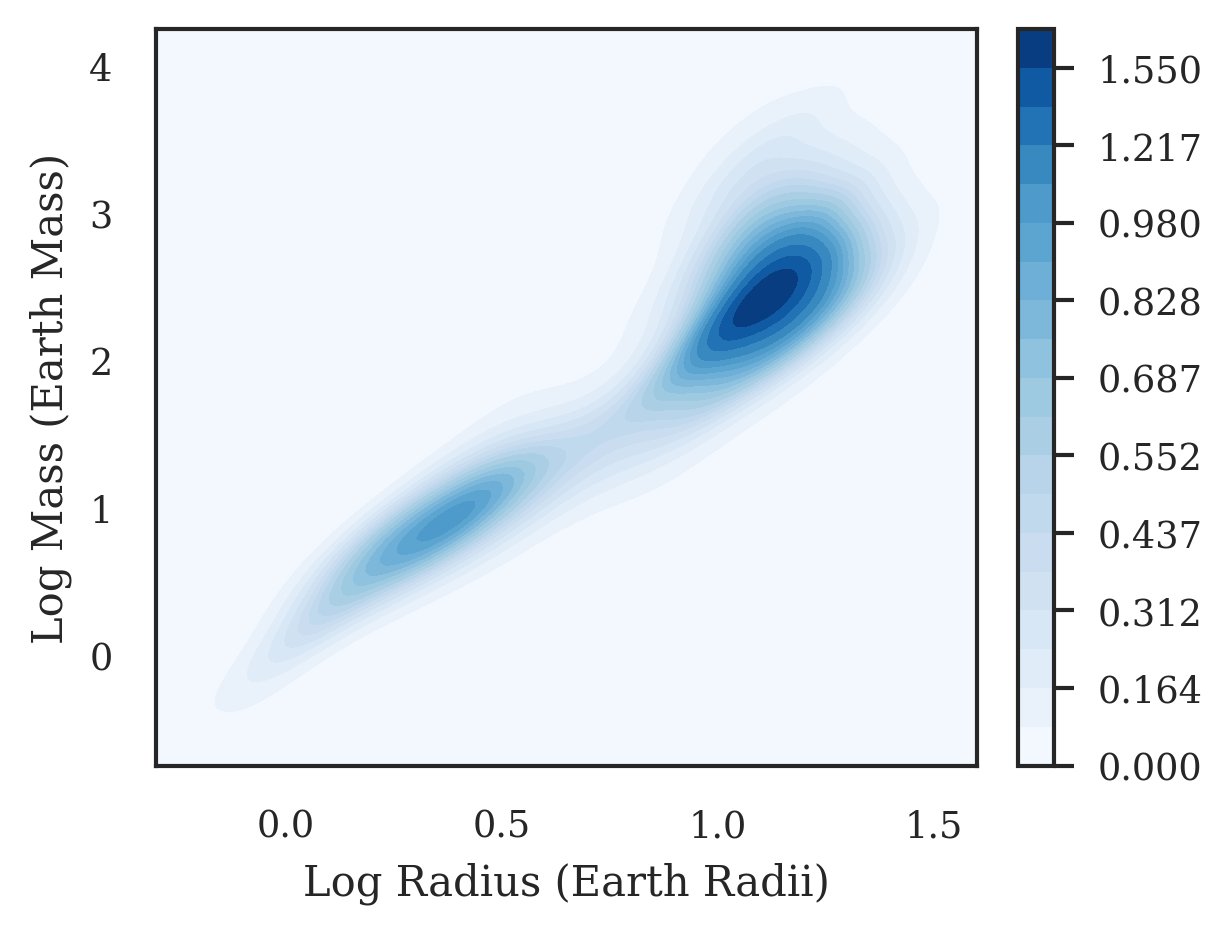

In [4]:
columns = ['radius', 'mass']

x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)
seaborn.kdeplot(pandas.DataFrame(numpy.log10(data[columns]), columns = columns), x = 'radius', y = 'mass', fill = True, cmap = 'Blues', levels = 20, thresh = 0, cbar = True)
# seaborn.scatterplot(numpy.log10(data[columns]), x = 'radius', y = 'mass', s = 5, color = 'black', zorder = 2)
# plot.gca().set_aspect('auto')

plot.xlim(-0.3, 1.6)
plot.ylim(-0.75, 4.25)

plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Mass (Earth Mass)')

# if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()

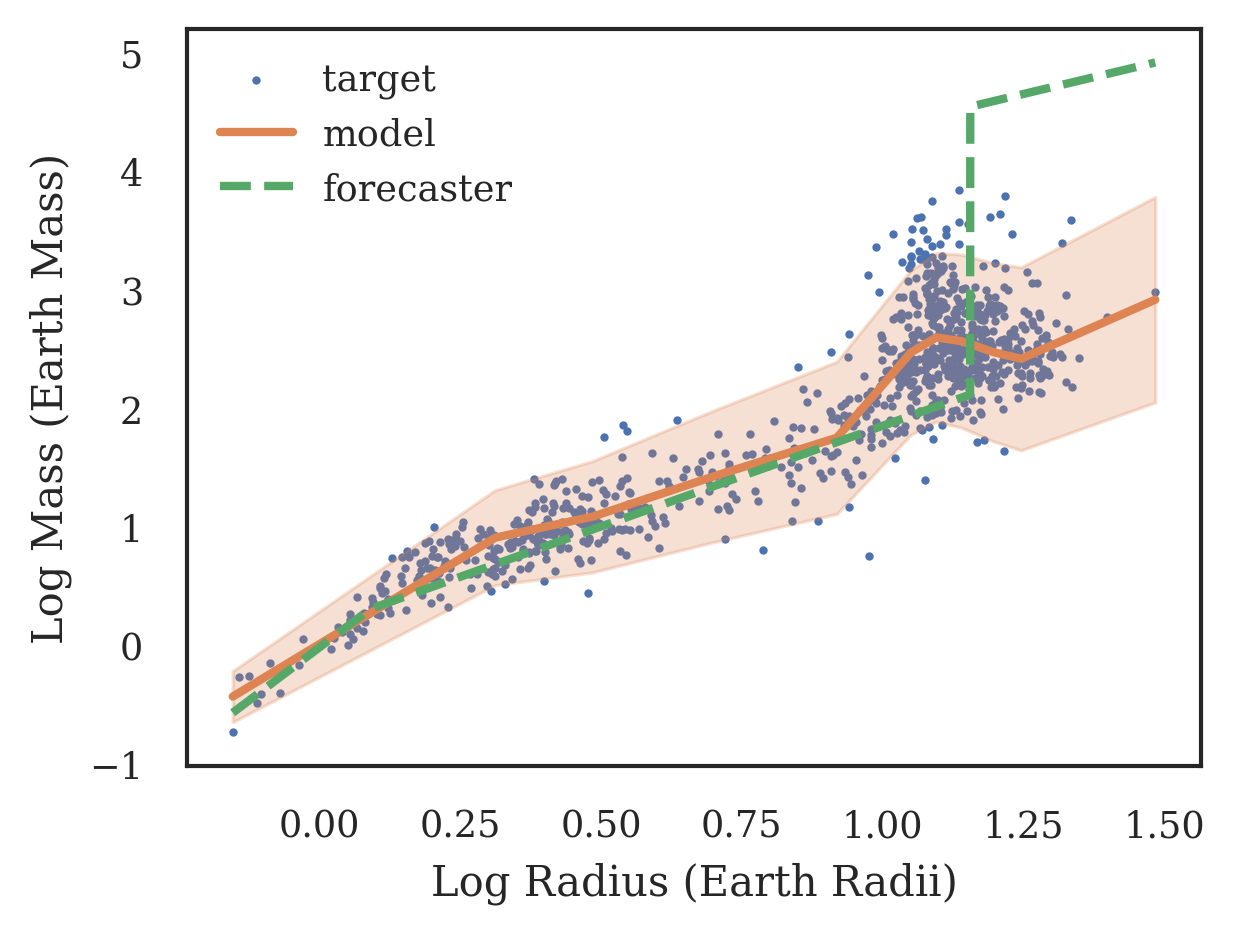

In [5]:
model = load_model()

xs = numpy.linspace(x.min(), x.max(), 10000)

ms = model(xs)
ms_e = model.error(xs)
ms2 = ForecasterRM.forecaster(xs)

plot.scatter(x, y)

plot.plot(xs, ms, color = 'C1')
plot.plot(xs, ms2, '--', color = 'C2')

plot.fill_between(xs, ms - ms_e, ms + ms_e, color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])

plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Mass (Earth Mass)')

if save: plot.savefig(f'{path}/Figure 2.jpeg')

plot.show()

In [6]:
m = model(x)
m_e = model.error(x)
m_e2 = numpy.linspace(numpy.std(model.errors), numpy.std(model.errors), len(x))
out_error = len(x[(y < (m - m_e)) | (y > (m + m_e))])
out_error2 = len(x[(y < (m - m_e2)) | (y > (m + m_e2))])
out_error / len(x), out_error2 / len(x), len(x)

(0.06673728813559322, 0.4141949152542373, 944)

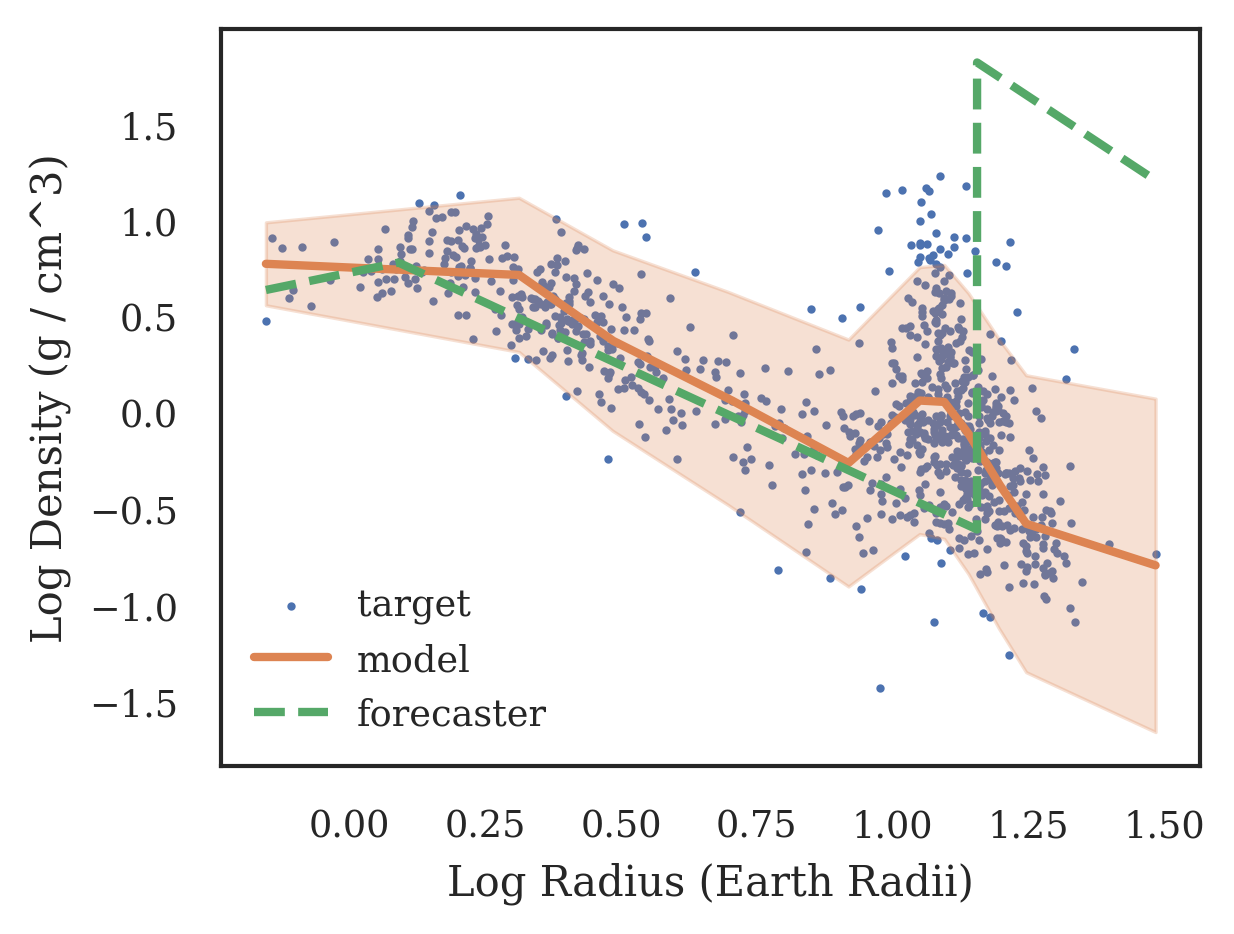

In [7]:
a = numpy.log10(5.51)  # Density of Earth in g / cm^3

plot.scatter(x, (y - 3 * x) + a)
ds = (ms - 3 * xs) + a
ds2 = (ms2 - 3 * xs) + a
plot.plot(xs, ds, color = 'C1')
plot.plot(xs, ds2, '--', color = 'C2')

plot.fill_between(xs,
                  ((ms - ms_e) - 3 * xs) + a,
                  ((ms + ms_e) - 3 * xs) + a,
                  color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Density (g / cm^3)')

if save: plot.savefig(f'{path}/Figure 4.jpeg')

plot.show()

In [8]:
ms1ts = []
ms2ts = []

for i in range(100):
    start_time = time.time()
    model(xs)
    ms1t = time.time() - start_time

    start_time = time.time()
    ForecasterRM.forecaster(xs)
    ms2t = time.time() - start_time

    ms1ts.append(ms1t)
    ms2ts.append(ms2t)

ms1t = numpy.mean(ms1ts) * 1e3
ms2t = numpy.mean(ms2ts) * 1e3

print('ExoRM time (ms): ', ms1t)
print('Forecaster time (ms): ', ms2t)

ExoRM time (ms):  0.10524988174438477
Forecaster time (ms):  0.1386404037475586


In [9]:
p_data = data.copy()
columns = ['radius', 'mass']
p_data[columns] = numpy.log10(p_data[columns])

p_data

,name,radius,mass,density
0,2MASS J02192210-3925225 b,1.207929,3.645210,1.050562
1,55 Cnc e,0.281033,0.907411,1.159608
2,BD-14 3065 b,1.334253,3.594614,0.390711
3,CFHTWIR-Oph 98 b,1.319079,3.394287,0.273558
4,CoRoT-1 b,1.222716,2.515012,0.070285
...,...,...,...,...
939,XO-3 b,1.134846,3.573691,1.476223
940,XO-4 b,1.173478,2.752594,0.170671
941,XO-5 b,1.106531,2.577722,0.181188
942,XO-7 b,1.186287,2.353451,0.062315


In [10]:
p_data['ExoRM'] = model(p_data['radius'])
p_data['Forecaster'] = ForecasterRM.forecaster(p_data['radius'])

p_data['ExoRM res'] = (p_data['mass'] - p_data['ExoRM'])
p_data['Forecaster res'] = (p_data['mass'] - p_data['Forecaster'])

p_data['name_len'] = p_data['name'].str.len()
p_data = p_data.sort_values(
    by = ['name_len', 'name'],
).reset_index(drop = True)
p_data = p_data.drop(columns = ['name_len'])

columns = ['radius', 'mass', 'ExoRM', 'Forecaster', 'ExoRM res', 'Forecaster res']

p_data[columns] = p_data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

p_data['winner'] = p_data.apply(
    lambda x: 'ExoRM' if abs(x['ExoRM res']) < abs(x['Forecaster res']) else 'Forecaster', axis = 1
)

if save: p_data[['name'] + columns + ['winner']].to_csv(f'{path}/ExoRM_results.csv', index = False)

p_data.head(10)

,name,radius,mass,density,ExoRM,Forecaster,ExoRM res,Forecaster res,winner
0,PH2 b,0.97021,1.93990,0.106982,2.0366,1.80430,-0.096704,0.135680,ExoRM
1,K2-3 b,0.31765,0.70842,0.569488,0.9175,0.69634,-0.209080,0.012079,Forecaster
2,XO-1 b,1.13090,2.46270,0.117469,2.5758,2.07710,-0.113130,0.385560,ExoRM
3,XO-3 b,1.13480,3.57370,1.476223,2.5731,2.08380,1.000600,1.489900,ExoRM
4,XO-4 b,1.17350,2.75260,0.170671,2.5137,4.56690,0.238900,-1.814400,ExoRM
5,XO-5 b,1.10650,2.57770,0.181188,2.5926,2.03570,-0.014908,0.542020,ExoRM
6,XO-7 b,1.18630,2.35350,0.062315,2.4925,4.58150,-0.139080,-2.228000,ExoRM
7,GPX-1 b,1.21690,3.79670,1.399615,2.4528,4.61620,1.343900,-0.819550,Forecaster
8,K2-18 b,0.41664,0.93601,0.485388,1.0185,0.86442,-0.082507,0.071596,Forecaster
9,K2-19 b,0.88874,1.45480,0.061464,1.7094,1.66590,-0.254590,-0.211100,Forecaster


In [11]:
p_data['ExoRM res'].abs().describe(), p_data['Forecaster res'].abs().describe()

(count    944.000000
 mean       0.246793
 std        0.228770
 min        0.000476
 25%        0.079090
 50%        0.185725
 75%        0.341730
 max        1.343900
 Name: ExoRM res, dtype: float64,
 count    944.000000
 mean       0.740914
 std        0.777275
 min        0.000266
 25%        0.150803
 50%        0.378175
 75%        1.145025
 max        2.969000
 Name: Forecaster res, dtype: float64)

In [12]:
p_data['winner'].value_counts() / len(p_data)

winner
ExoRM         0.75
Forecaster    0.25
Name: count, dtype: float64

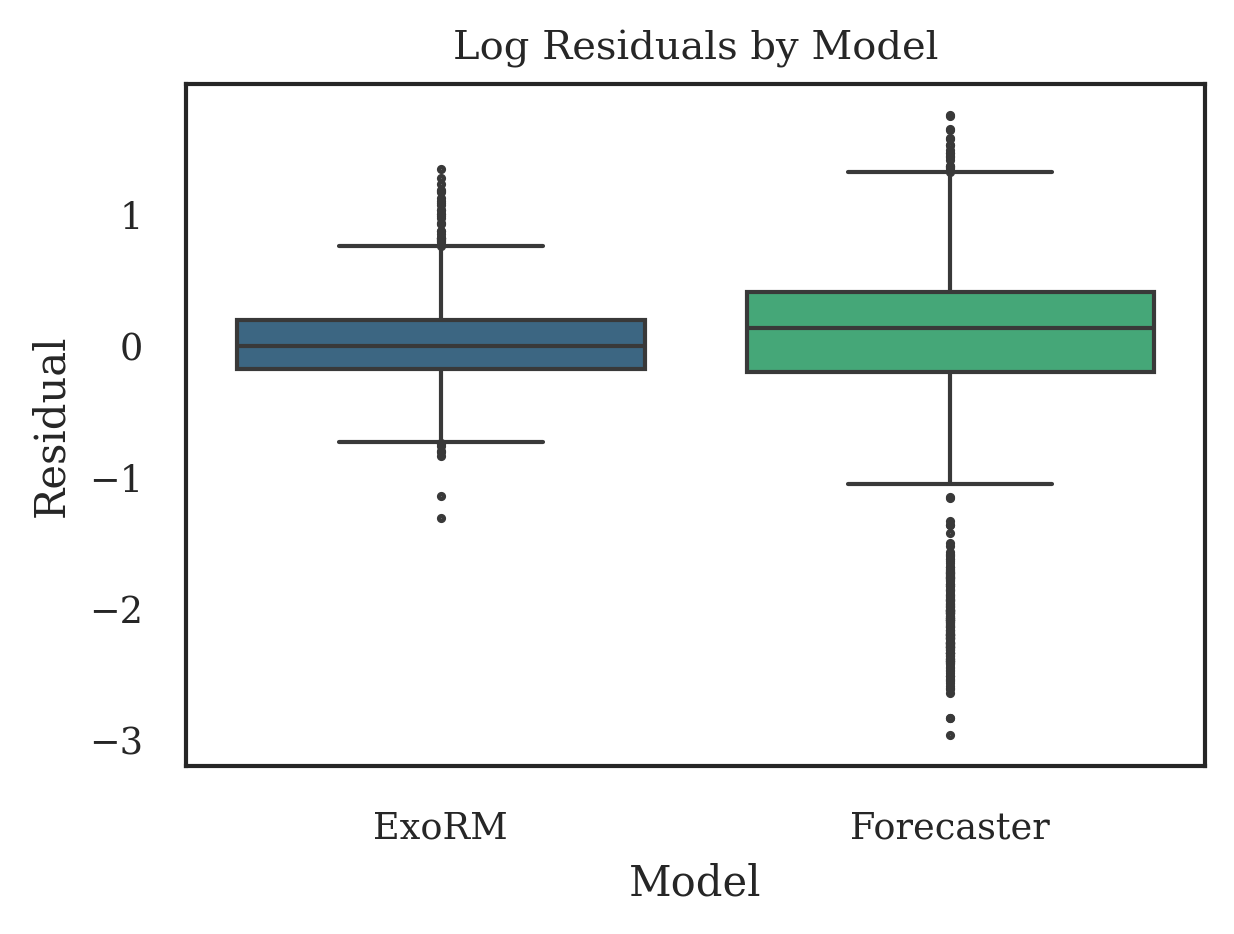

,Model,Residual
0,ExoRM,-0.096704
1,ExoRM,-0.209080
2,ExoRM,-0.113130
3,ExoRM,1.000600
4,ExoRM,0.238900
...,...,...
1883,Forecaster,0.235660
1884,Forecaster,0.292540
1885,Forecaster,0.050698
1886,Forecaster,-0.160330


In [13]:
p_data_long = pandas.melt(
    p_data,
    value_vars = ['ExoRM res', 'Forecaster res'],
    var_name = 'Model',
    value_name = 'Residual'
)

p_data_long['Model'] = p_data_long['Model'].map(lambda x: 'ExoRM' if x == 'ExoRM res' else 'Forecaster')
seaborn.boxplot(data = p_data_long, x = 'Model', y = 'Residual', hue = 'Model', palette = 'viridis', zorder = 1)

plot.title('Log Residuals by Model')

if save: plot.savefig(f'{path}/Figure 3.jpeg')

plot.show()

p_data_long

In [14]:
10 ** xs[numpy.argmin(numpy.abs((10 ** ms2) - 317.9 * 13))]
# the deuterium burning limit radius

14.29790619332777

In [15]:
numpy.mean(numpy.abs(ms - ms2))
# average change metween two models

0.5422199403024273

In [16]:
10 ** xs[numpy.argmin(ds)], 10 ** xs[numpy.argmax(ds)], 10 ** xs[numpy.argmin(ds2)], 10 ** xs[numpy.argmax(ds2)]
# min and max density points for both models

(30.488479999999992, 0.701, 14.29790619332777, 14.3033017733883)

In [17]:
10 ** min(ds), 10 ** max(ds), 10 ** min(ds2), 10 ** max(ds2)
# min and max density values for both models

(0.16115695434358557, 5.953125119205243, 0.24762439389807675, 66.2686947592525)

In [18]:
exoplanet_data = read_exoplanet_data()

exoplanet_data[['name', 'radius', 'mass', 'year']] = exoplanet_data[['pl_name', 'pl_rade', 'pl_bmasse', 'disc_year']]
exoplanet_data = exoplanet_data[exoplanet_data['pl_controv_flag'] == 0]
exoplanet_data = exoplanet_data.drop(columns = ['pl_controv_flag', 'pl_name', 'pl_rade', 'pl_bmasse', 'disc_year'])
exoplanet_data = exoplanet_data[exoplanet_data['radius'].notna() & exoplanet_data['mass'].notna()]
exoplanet_data[['radius', 'mass']] = numpy.log10(exoplanet_data[['radius', 'mass']])

old_exoplanet_data = exoplanet_data[exoplanet_data['year'] < 2017].copy()
new_exoplanet_data = exoplanet_data[exoplanet_data['year'] >= 2017].copy()

new_exoplanet_data = new_exoplanet_data.sort_values(by = ['name', 'year'], ascending = [True, False]).drop_duplicates(subset = 'name').reset_index(drop = True)
old_exoplanet_data = old_exoplanet_data.sort_values(by = ['name', 'year'], ascending = [True, False]).drop_duplicates(subset = 'name').reset_index(drop = True)
new_exoplanet_data, old_exoplanet_data

(                 name    radius      mass  year
 0        BD-14 3065 b  1.334253  3.594614  2024
 1    CFHTWIR-Oph 98 b  1.319079  3.394287  2021
 2          CoRoT-30 b  1.053458  2.964593  2020
 3          CoRoT-35 b  1.274875  2.543585  2022
 4    EPIC 201595106 b  0.194514  0.884795  2021
 ..                ...       ...       ...   ...
 541        Wolf 327 b  0.093422  0.403121  2024
 542        Wolf 503 b  0.310268  0.797268  2018
 543            XO-7 b  1.186287  2.353451  2019
 544  ZTF J1828+2308 b  1.046515  3.803223  2025
 545          pi Men c  0.324282  0.633468  2018
 
 [546 rows x 4 columns],
                           name    radius      mass  year
 0    2MASS J02192210-3925225 b  1.207929  3.645210  2015
 1                     55 Cnc e  0.281033  0.907411  2004
 2                    CoRoT-1 b  1.222716  2.515012  2008
 3                   CoRoT-10 b  1.036230  2.941511  2010
 4                   CoRoT-11 b  1.203686  2.871411  2010
 ..                         ...      

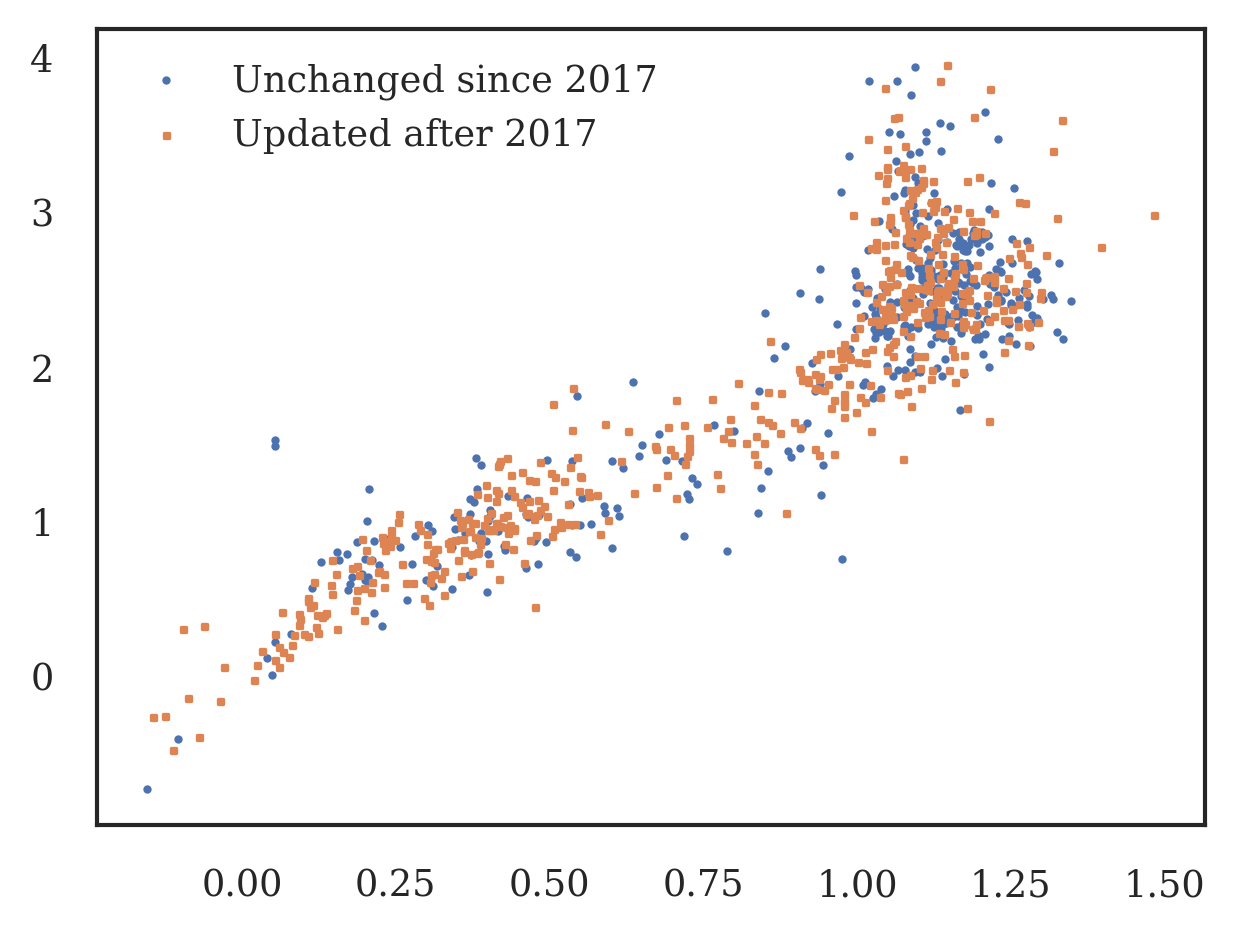

In [19]:
plot.scatter(old_exoplanet_data['radius'], old_exoplanet_data['mass'], marker = 'o')
plot.scatter(new_exoplanet_data['radius'], new_exoplanet_data['mass'], marker = 's')

plot.legend(['Unchanged since 2017', 'Updated after 2017'])

if save: plot.savefig(f'{path}/Figure 1.jpeg')